In [119]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import matplotlib.pyplot as plt
import pydeck as pdk
import streamlit as st

<b>First</b> I want to bring in my dataset to start playing with the data

In [3]:
df = pd.read_csv('data-2026-03.csv', names=['siteid', 'direction', 'type', 'start', 'end', 'count'])

In [4]:
sites = pd.read_csv('sites.csv', names=['siteid', 'site_nr', 'longitude', 'latitude', 'name', 'region', 'direction_number', 'district', 'municipality', 'interval', 'date'])

In [5]:
df.head(10)

,siteid,direction,type,start,end,count
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0
5,1,IN,FIETSERS,2026-03-01 01:15:00.0,2026-03-01 01:30:00.0,0.0
6,1,IN,FIETSERS,2026-03-01 01:30:00.0,2026-03-01 01:45:00.0,1.0
7,1,IN,FIETSERS,2026-03-01 01:45:00.0,2026-03-01 02:00:00.0,0.0
8,1,IN,FIETSERS,2026-03-01 02:00:00.0,2026-03-01 02:15:00.0,0.0
9,1,IN,FIETSERS,2026-03-01 02:15:00.0,2026-03-01 02:30:00.0,0.0


Will want to group sites into a smaller classification so they can be clustered. Maybe group by hour by splitting the start and end times into the hours?

In [6]:
#break the start and end into its component parts
#takes about 4 mins 21 secs to run
df['start_date'] = 'NULL'
df['start_time'] = 0
df['end_date'] = 'NULL'
df['end_time'] = 0




for index, val in df.iterrows():
    df.loc[index, 'start_date'] = df.loc[index, 'start'][:10]
    df.loc[index, 'start_date'] = df.loc[index, 'start_date'][:10]
    
    df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
    df.loc[index, 'start_time'] = df.loc[index, 'start_time'][:]

    df.loc[index, 'end_date'] = df.loc[index, 'end'][:10]
    df.loc[index, 'end_date'] = df.loc[index, 'end_date'][:10]

    df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]
    df.loc[index, 'end_time'] = df.loc[index, 'end_time'][:]





/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/2812288398.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:00:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/2812288398.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:15:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]


Next I want to add some features to better map the space I can work with.

The list of these is below:
1. Is it the weekend? 1 if yes else 0
2. Sum per hour and create a new column called hour with an integer representing the hour
3. Maybe a month specific qualifier? Like is_summer or is_winter?
4. TBD once I continue working I can try and implement something new
5. Direction, 1 in IN 0 else

In [8]:
for index, val in df.iterrows():
    df.loc[index, 'hour'] = pd.to_numeric(df.loc[index, 'start_time'][:2])

In [9]:
#this works
df['hour_count'] = df.groupby(['siteid', 'start_date', 'hour', 'direction'])['count'].cumsum()

In [11]:
for index, val in df.iterrows():
    insert_val = 0
    if df.loc[index, 'direction'] == 'IN':
        insert_val = 1
    df.loc[index, 'direction_binary'] = insert_val

In [12]:
for index, val in df.iterrows():
    insert_val = 0
    if df.loc[index, 'start_date'] == '2026-03-01':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-07' or df.loc[index, 'start_date'] == '2026-03-08':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-14' or df.loc[index, 'start_date'] == '2026-03-15':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-21':
        insert_val = 1
    df.loc[index, 'is_weekend'] = insert_val

In [97]:
for index, val in df.iterrows():
    df.loc[index, 'day'] = pd.to_numeric(df.loc[index, 'start_date'][-2:])

In [96]:
df

,siteid,direction,type,start,end,count,start_date,start_time,end_date,end_time,hour,hour_count,direction_binary,is_weekend,day,average_counts
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0,2026-03-01,00:00:00.0,2026-03-01,00:15:00.0,0.0,0.0,1.0,1.0,1.0,5.780680
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0,2026-03-01,00:15:00.0,2026-03-01,00:30:00.0,0.0,0.0,1.0,1.0,1.0,14.390537
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0,2026-03-01,00:30:00.0,2026-03-01,00:45:00.0,0.0,0.0,1.0,1.0,1.0,12.739112
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0,2026-03-01,00:45:00.0,2026-03-01,01:00:00.0,0.0,0.0,1.0,1.0,1.0,3.143615
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0,2026-03-01,01:00:00.0,2026-03-01,01:15:00.0,1.0,1.0,1.0,1.0,1.0,2.966903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573069,152,OUT,FIETSERS,2026-03-21 03:45:00.0,2026-03-21 04:00:00.0,0.0,2026-03-21,03:45:00.0,2026-03-21,04:00:00.0,3.0,0.0,0.0,1.0,NaN,NaN
573070,152,OUT,FIETSERS,2026-03-21 04:00:00.0,2026-03-21 04:15:00.0,0.0,2026-03-21,04:00:00.0,2026-03-21,04:15:00.0,4.0,0.0,0.0,1.0,NaN,NaN
573071,152,OUT,FIETSERS,2026-03-21 04:15:00.0,2026-03-21 04:30:00.0,0.0,2026-03-21,04:15:00.0,2026-03-21,04:30:00.0,4.0,0.0,0.0,1.0,NaN,NaN
573072,152,OUT,FIETSERS,2026-03-21 04:30:00.0,2026-03-21 04:45:00.0,0.0,2026-03-21,04:30:00.0,2026-03-21,04:45:00.0,4.0,0.0,0.0,1.0,NaN,NaN


In [15]:
df1 = df[['siteid', 'hour', 'hour_count', 'is_weekend', 'day', 'direction_binary']]

In [16]:
#df1[df1.isna()]
# Source - https://stackoverflow.com/a/37755016
# Posted by michael_j_ward
# Retrieved 2026-05-20, License - CC BY-SA 3.0

#np.argwhere(np.isnan(df1))


df1.loc[:, ['hour_count']] = df1.loc[:, ['hour_count']].fillna(0)
df1.iloc[256754, 2]

#df1

np.float64(0.0)

In [ ]:
#need to do some group bys to try and get better data
#Min count, min count hour, max count, max count hour, min count direction, max count direction, siteid

temp_df4 = df1.groupby('siteid')['hour_count'].idxmax()

temp_df7 = df1.groupby('siteid')['hour_count'].mean()

#df1

In [21]:
df_cluster = pd.DataFrame()
indx_count = 0
indx_count2 = 0

for indx in temp_df4:
    df_cluster.loc[indx_count, 'siteid'] = temp_df4.index[indx_count]
    df_cluster.loc[indx_count, 'max_hour_count'] = df1.loc[indx, 'hour_count']
    df_cluster.loc[indx_count, 'max_hour'] = df1.loc[indx, 'hour']
    df_cluster.loc[indx_count, 'max_direction'] = df1.loc[indx, 'direction_binary']
    indx_count += 1
    
#include averages
for index in temp_df7:
    df_cluster.loc[indx_count2, 'average_hour_count'] = index
    indx_count2 += 1



In [23]:
df_cluster

#average count per hour as columns in the dataset

,siteid,max_hour_count,max_hour,max_direction,average_hour_count
0,1.0,64.0,10.0,1.0,5.727577
1,2.0,238.0,8.0,1.0,14.259928
2,3.0,203.0,16.0,0.0,12.619588
3,4.0,60.0,11.0,0.0,3.116435
4,5.0,57.0,16.0,0.0,2.935494
...,...,...,...,...,...
140,148.0,88.0,17.0,1.0,6.185149
141,149.0,48.0,8.0,1.0,4.845050
142,150.0,42.0,15.0,0.0,2.061386
143,151.0,30.0,8.0,1.0,2.601733


Below is the creation of the different clustering algorithms. First is KMeans, chosen due to its common usage. I chose three clusters as when I chose 2 it was clear the split was occuring based on the highest and lowest sites by count which is not really interesting to see. Second is X, chosen due to Y. Finally is Z, which is chosen due to W.

In [113]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto').fit_predict(df_cluster)

In [114]:
agc = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(df_cluster)

In [131]:
dbscan = DBSCAN(min_samples=2).fit_predict(df_cluster)

In [25]:
df2 = df_cluster.copy()

In [133]:
df2['cluster'] = kmeans
df2['cluster_agc_ward'] = agc
df2['cluster_dbscan'] = dbscan

In [40]:

df_testing_now = df.groupby(['siteid', 'hour'])['hour_count'].mean()

indz = 0
num = 0
for val in df_testing_now:
    df2.loc[indz, str(num)] = val
    if num < 23:
        num += 1
    else:
        num = 0
        indz += 1

#for val in 

In [134]:
df2[0:]

,siteid,max_hour_count,max_hour,max_direction,average_hour_count,cluster,0,1,2,3,...,17,18,19,20,21,22,23,average_counts,cluster_agc_ward,cluster_dbscan
0,1.0,64.0,10.0,1.0,5.73,0,0.386905,0.392857,0.630952,0.273810,...,15.493750,7.862500,5.418750,2.637500,2.187500,2.006250,1.250000,5.780680,0,-1
1,2.0,238.0,8.0,1.0,14.26,2,1.505952,0.809524,0.785714,0.761905,...,24.287500,15.031250,9.212500,8.243750,4.693750,5.006250,1.493750,14.390537,2,-1
2,3.0,203.0,16.0,0.0,12.62,2,2.226190,1.523810,0.857143,0.398810,...,30.656250,21.237500,12.668750,6.993750,6.043750,7.843750,4.218750,12.739112,2,-1
3,4.0,60.0,11.0,0.0,3.12,0,0.154762,0.107143,0.220238,0.309524,...,4.475000,2.806250,2.625000,1.706250,1.243750,0.775000,0.343750,3.143615,0,-1
4,5.0,57.0,16.0,0.0,2.94,0,0.354167,0.326389,0.291667,0.034722,...,6.345588,3.897059,2.904412,1.970588,1.191176,0.955882,0.323529,2.966903,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,148.0,88.0,17.0,1.0,6.19,0,0.301136,0.125000,0.041667,0.000000,...,19.285714,14.821429,5.345238,1.446429,0.833333,0.738095,0.452381,6.196823,0,-1
141,149.0,48.0,8.0,1.0,4.85,0,0.125000,0.136905,0.041667,0.029762,...,15.517857,10.267857,3.672619,2.095238,0.988095,0.738095,0.244048,4.854415,0,-1
142,150.0,42.0,15.0,0.0,2.06,0,0.153409,0.047619,0.160714,0.000000,...,6.071429,3.982143,1.464286,0.755952,0.375000,0.196429,0.125000,2.065172,0,-1
143,151.0,30.0,8.0,1.0,2.60,0,0.284091,0.196429,0.136905,0.071429,...,7.458333,5.059524,2.404762,1.488095,1.077381,0.857143,0.398810,2.606331,0,-1


In [30]:
df_cluster[-10:]

,siteid,max_hour_count,max_hour,max_direction,average_hour_count,0,1,2,3,4,...,14,15,16,17,18,19,20,21,22,23
135,140.0,236.0,15.0,0.0,30.634605,3.898810,2.541667,1.815476,1.196429,1.325301,...,46.687500,74.075000,72.831250,61.600000,41.537500,26.868750,16.256250,14.437500,11.912500,5.562500
136,143.0,575.0,8.0,1.0,67.161466,12.063218,8.232143,4.863095,3.720238,4.357143,...,95.892857,116.910714,195.220238,159.202381,102.208333,65.589286,45.119048,36.678571,29.809524,18.488095
137,145.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
138,146.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
139,147.0,41.0,7.0,1.0,2.453713,0.380682,0.208333,0.089286,0.065476,0.035714,...,3.380952,5.107143,6.458333,6.041667,4.684524,2.470238,1.458333,0.702381,0.446429,0.440476
140,148.0,88.0,17.0,1.0,6.185149,0.301136,0.125000,0.041667,0.000000,0.077381,...,9.797619,10.976190,13.095238,19.285714,14.821429,5.345238,1.446429,0.833333,0.738095,0.452381
141,149.0,48.0,8.0,1.0,4.845050,0.125000,0.136905,0.041667,0.029762,0.184524,...,6.696429,9.910714,13.392857,15.517857,10.267857,3.672619,2.095238,0.988095,0.738095,0.244048
142,150.0,42.0,15.0,0.0,2.061386,0.153409,0.047619,0.160714,0.000000,0.065476,...,4.285714,4.255952,4.696429,6.071429,3.982143,1.464286,0.755952,0.375000,0.196429,0.125000
143,151.0,30.0,8.0,1.0,2.601733,0.284091,0.196429,0.136905,0.071429,0.005952,...,3.226190,4.488095,6.369048,7.458333,5.059524,2.404762,1.488095,1.077381,0.857143,0.398810
144,152.0,66.0,12.0,0.0,6.580155,0.184524,0.065476,0.095238,0.119048,0.482143,...,14.850000,16.400000,19.418750,15.937500,8.962500,2.525000,1.212500,1.631250,0.962500,0.456250


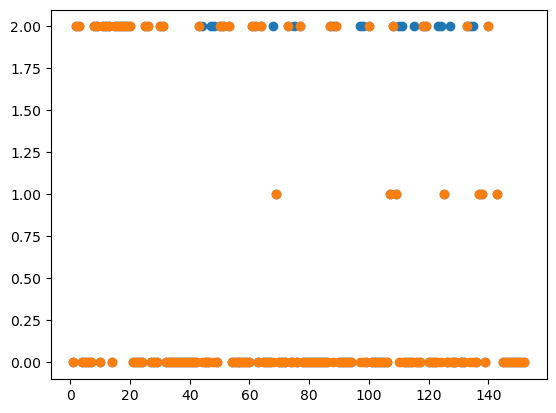

In [136]:
fig, ax = plt.subplots()
ax.scatter(df2['siteid'], df2['cluster'])
ax.scatter(df2['siteid'], df2['cluster_agc_ward'])

#plt.savefig('testing.png', dpi=500)
#df2[['siteid', 'cluster']]

I need a way to group each site so I can then run k-means and get clusters PER SITE not per recorded instance

weights per hour based on count to indicate where the most rides occur

maybe max and min hours or max and min counts? remove direction

Hour with max cyclists per day and then average those

In [145]:
df_varun = pd.DataFrame()
varun_list = []
for num in range(0, 24):
    a = df2.groupby('cluster')[str(num)].mean()
    for val in a:
        varun_list.append(val)



In [144]:
indz = 0
num = 0
for val in varun_list:
    df_varun.loc[indz, str(num)] = val
    if indz < 2:
        indz += 1
    else:
        indz = 0
        num += 1


#varun_list

In [143]:
site_location_dict = {}

for index, value in sites[['siteid','longitude', 'latitude']].iterrows():
    site_location_dict[value[0]] = [value[1], value[2]]

/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/1571555356.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  site_location_dict[value[0]] = [value[1], value[2]]


In [146]:
df2['average_hour_count'] = round(df2['average_hour_count'], 2)

In [147]:
sites_updated = df2[['siteid', 'cluster', 'cluster_agc_ward', 'average_hour_count']].copy()

In [148]:
for index, val in sites_updated.iterrows():
    if val.siteid in site_location_dict:
        sites_updated.loc[index, 'longitude'] = site_location_dict[val.siteid][0]
        sites_updated.loc[index, 'latitude'] = site_location_dict[val.siteid][1]

In [149]:
for index, val in sites_updated.iterrows():
    if val.cluster == 0:
        sites_updated.loc[index, 'color1'] = 20
        sites_updated.loc[index, 'color2'] = 20
        sites_updated.loc[index, 'color3'] = 255
    elif val.cluster == 1:
        sites_updated.loc[index, 'color1'] = 255
        sites_updated.loc[index, 'color2'] = 20
        sites_updated.loc[index, 'color3'] = 20
    else:
        sites_updated.loc[index, 'color1'] = 20
        sites_updated.loc[index, 'color2'] = 255
        sites_updated.loc[index, 'color3'] = 20

for index, val in sites_updated.iterrows():
    if val.cluster_agc_ward == 0:
        sites_updated.loc[index, 'color1.2'] = 20
        sites_updated.loc[index, 'color2.2'] = 20
        sites_updated.loc[index, 'color3.2'] = 255
    elif val.cluster == 1:
        sites_updated.loc[index, 'color1.2'] = 255
        sites_updated.loc[index, 'color2.2'] = 20
        sites_updated.loc[index, 'color3.2'] = 20
    else:
        sites_updated.loc[index, 'color1.2'] = 20
        sites_updated.loc[index, 'color2.2'] = 255
        sites_updated.loc[index, 'color3.2'] = 20

In [150]:
sites_updated.to_csv('sites_cluster.csv', index=False)

In [ ]:
pd.unique(df['siteid'])

#NO 52, 95, 96, 130, 141, 142, 144

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134,
       135, 136, 137, 138, 139, 140, 143, 145, 146, 147, 148, 149, 150,
       151, 152])